# Import the Data

In this section we import the data from the website and csv files and put it in two dataframes. The df_image dataframe contains information about what we can see on the cartoon. The df_caption dataframe contains the captions provided by the users and how many votes they got. 

In [2]:

#import all the packages

import sys, os
sys.path.append(os.path.abspath("src"))
from utils.utils_import import *
from src.utils.evaluation_utils import *

/Users/yann/anaconda3/envs/ada/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Creation of dataframes and preprocessing

In [2]:
import importlib
import src.data.dataloader
from src.data.dataloader import get_image_data, get_caption_dataset

df_image = get_image_data()
df_caption = get_caption_dataset(df_image)

save_to_csv(df_image, 'data/newyorker_caption_contest/df_complete.csv')

In [3]:
df_caption.head(5)

,contest_id,date,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny
0,510,2016-03-07,0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18
1,510,2016-03-07,1,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5
2,510,2016-03-07,2,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8
3,510,2016-03-07,3,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3
4,510,2016-03-07,4,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6


In [4]:
df_image.head(5)

,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,Number of votes
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198


# Analysis of the contest dataset's captions

This section present a detailed exploration of the relationships between word mentions in captions. The analysis investigates how words specific to a political or global event appear in image captions over time.

Additionally, a Berchtel like test was done to analyse the times wordgroups for women compared with those fore men mentioned. This is further analysed for an interaction analysis


First, we took 50 captions of each contest image with the highest ranks to check what words are the most frequent in the captions, in general.

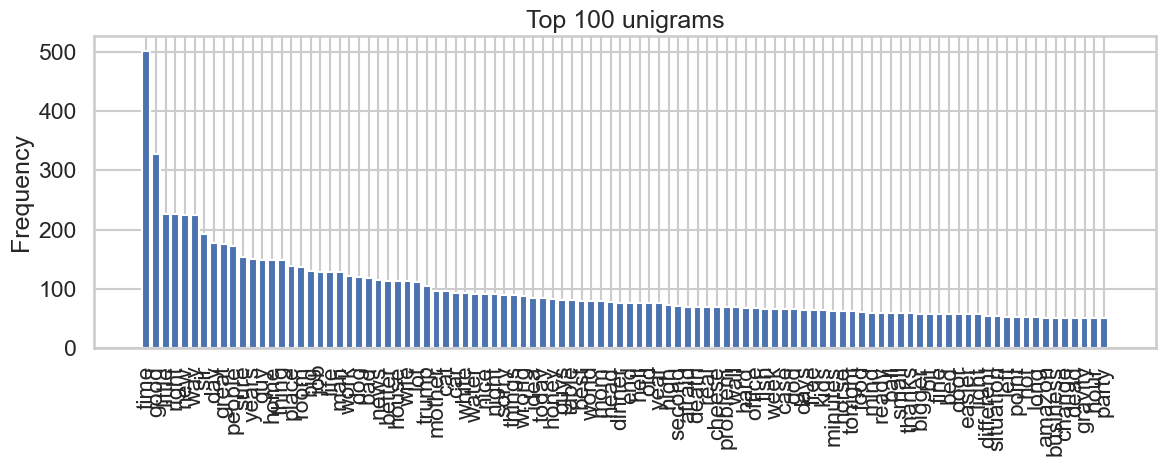

In [5]:
top_captions = df_caption.groupby('contest_id', group_keys=False).apply(lambda x: x.nlargest(50, 'votes'))
    
top_captions_list = top_captions['caption'].dropna().astype(str).tolist()

vocab, counts = count_terms(top_captions_list)
top_vocab, top_counts = top_terms(vocab, counts)
plot_top_terms(top_vocab, top_counts)

We can see that the word `time` is by far the most frequent word, as it appears 500 times in the most funny captions. Most words do not give many information, but some statistics are interesting. For example, words to describe a man are quite frequent (`sir`, `guy`, `man`, `guys`), while words to describe a woman are less frequent (`wife`, `mother`, `mom`), and all of them describe the "role" (wife / mother) of the woman, and not the individual in general.

Also, we can see that the word `Trump` is the 30th most used word in caption. Thus, we will analyze whether this word is used only during a certain period of time, e.g. when Trump is president.

11156 captions containing the word 'Trump'.
235 captions ranked under 100 contain the word 'Trump'.


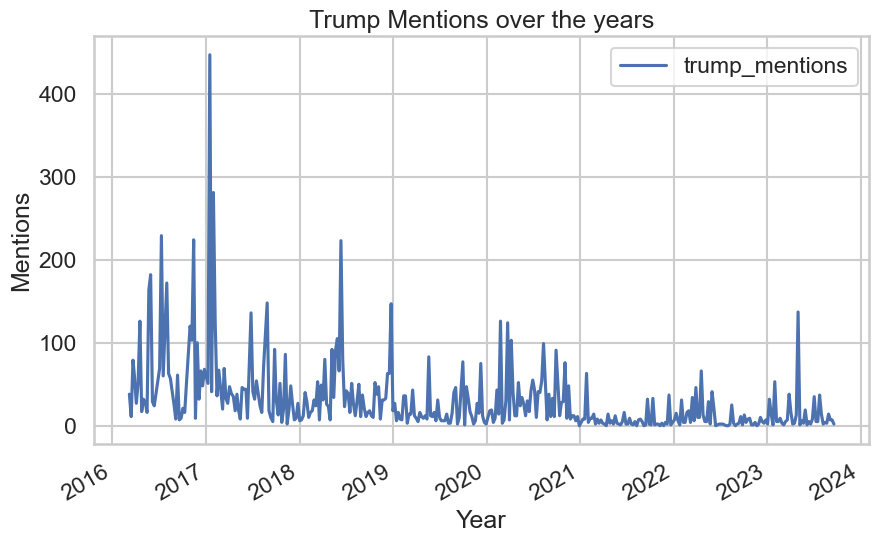

In [6]:
# at which frequency do captions mention Trump ?

mask = df_caption['caption'].str.contains(r'\btrump\b', case=False, na=False)
print(f"{mask.sum()} captions containing the word 'Trump'.")

df_trump = df_caption.loc[mask & (df_caption['rank'] < 100), ['date', 'rank', 'caption']]
print(f"{len(df_trump)} captions ranked under 100 contain the word 'Trump'.")

df_caption['trump_mentions'] = df_caption['caption'].str.count(r'\btrump\b', flags=re.IGNORECASE)
trump_counts = (df_caption.groupby('date')['trump_mentions'].sum().sort_index().reset_index())

trump_counts.plot(x='date', y='trump_mentions', title='Trump Mentions over the years')
plt.xlabel('Year')
plt.ylabel('Mentions')
plt.show()

The figure shows that Trump is mentioned frequently over time, and the frequency fluctuates following a pattern. A massive surge in mentions is visible around 2016-2017, corresponding to Trump's presidential campaign and early presidency. Media and public attention were extremely high during this time. Then, after 2017, the mentions frequency shows a downward trend. This likely reflects a normalization effect, where Trump remained relevant but no longer dominated headlines as much as during the election and early administration. Around 2019-20220, moderate peaks appear, which are possibly tied to the 2020 election and a major political event. Following his departure from office, the mentions drop, even if he still apears occasionally. Finally Trump's mentions increase again mid-2023, where Trump announced his run for presidency again.

Because the analysis about Trump's mentions' frequency of appearance gave us interesting results, we decided to visualize the word 'COVID' wit the same way, even if this word does not appear frequently according to the figure showing the top 50 unigrams.

4615 captions containing the word 'COVID'.
22 captions ranked under 100 contain the word 'COVID'.


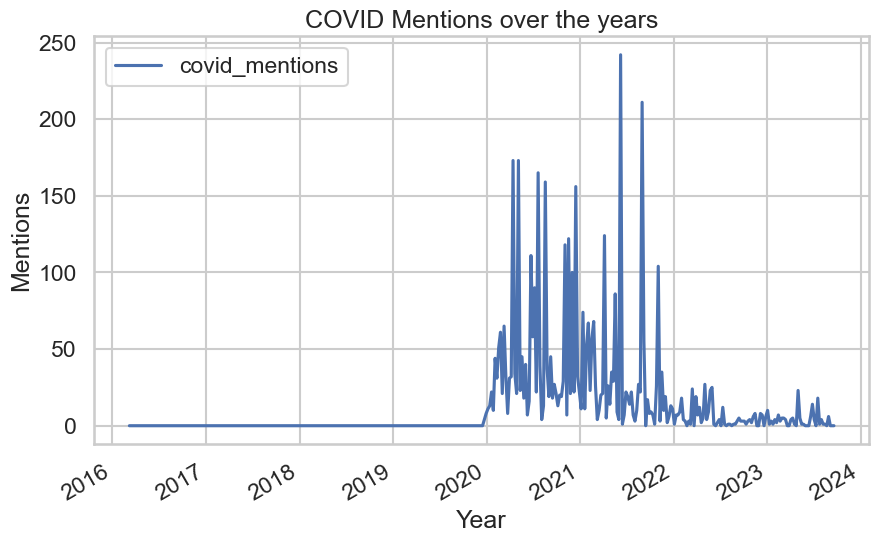

In [7]:
# at which frequency do captions mention Trump ?

mask = df_caption['caption'].str.contains(r'\bcovid\b', case=False, na=False)
print(f"{mask.sum()} captions containing the word 'COVID'.")

df_covid = df_caption.loc[mask & (df_caption['rank'] < 100), ['date', 'rank', 'caption']]
print(f"{len(df_covid)} captions ranked under 100 contain the word 'COVID'.")

df_caption['covid_mentions'] = df_caption['caption'].str.count(r'\bcovid\b', flags=re.IGNORECASE)
covid_counts = (df_caption.groupby('date')['covid_mentions'].sum().sort_index().reset_index())

covid_counts.plot(x='date', y='covid_mentions', title='COVID Mentions over the years')
plt.xlabel('Year')
plt.ylabel('Mentions')
plt.show()

Here, the word 'COVID' seems to appear abruptly in eaerly 2020, in the same time as the pandemic, and the mentions kept going until late 2022, where the pandemic was slowly attenuating around the world.

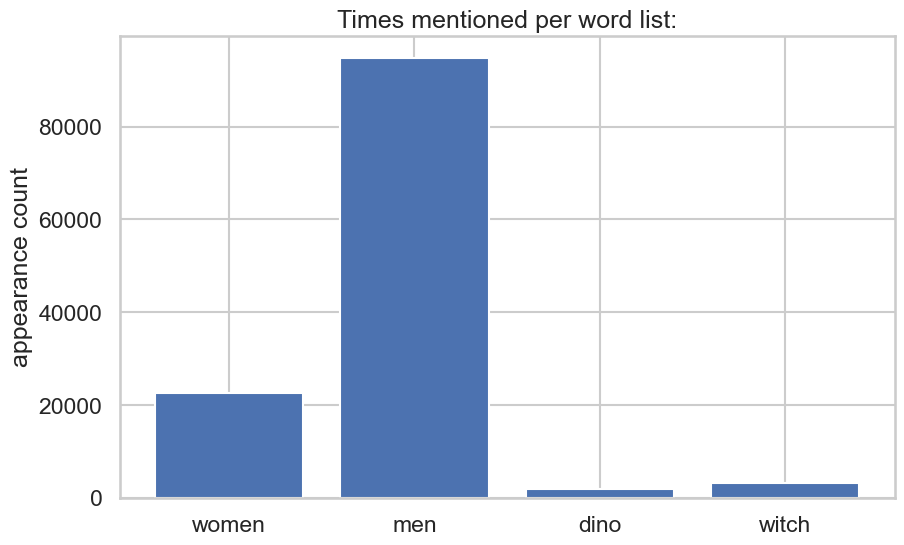

In [8]:
#plot the counts of the wordlist for all the data together as a boxplot
coutdict = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband|sir",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "onlywomen": "women"
}
counts = do_counts(df_caption['caption'].copy(), coutdict)


fig, ax = plt.subplots()
words = ['women',  'men', 'dino', 'witch'] #think about substracting women from men!!!!
counts[1] = counts[1]- counts[4]
ax.bar(words, counts[:4])
ax.set_ylabel('appearance count')
ax.set_title('Times mentioned per word list:')
plt.show()

Here, the wordanalysis is redone with wordgroups insead of only singular words. This is done to have broader results. Like this the bias for the use of the word "men" when talking about humanity is lowered. Additionally, the wordlist men is substracted by the wordlist for the word "women" since it contains the word "men".

The results are shocking. Even a unpolitical caption contest that pobabely even tries to have an equal amount of genders represented, there is a bit gab between women and men mentions.
Addtionally, when cheking on the camptions an images, it is also clear that there is almost never a women alone on a image (unless it is a witch).

So, the Berchtel test (form movies) applied on the cartoons:
- The *cartoon* has to have at least two women in it,
- who talk to each other,
- about something other than a man

this wasn't observed to happen...

source: https://en.wikipedia.org/wiki/Bechdel_test (24.11.25)

In [9]:
coutdict = {
  "women_count": "women",
  "men": "men|boy|father|husband|sir", 
  "women": "women|girl|mother|wife",
  "trump": "trump|donald|president"
  
}

###Analyse the mentions over time

#find all IDs:
ids = np.array(df_caption['contest_id'].copy().drop_duplicates())
per_contest = []
votes = []
funny = []
not_funny = []
somewhat_funny = []

for i in range(len(ids)):
    df_ID = df_caption[df_caption['contest_id'] == ids[i]]
    per_contest.append(do_counts(df_ID['caption'].copy(), coutdict))
    votes.append(df_ID['votes'].sum())
    funny.append(df_ID['funny'].sum())
    not_funny.append(df_ID['not_funny'].sum())
    somewhat_funny.append(df_ID['somewhat_funny'].sum())
per_contest = np.array(per_contest)
print()

df_vc = pd.DataFrame(per_contest, columns=["w", "men", "women", "trump"])
df_vc['votes'] = votes
df_vc['men'] = df_vc["men"]-df_vc["w"]
df_vc['contest_ids'] = ids
df_vc['funny'] = funny
df_vc['not_funny'] = not_funny
df_vc['somewhat_funny'] = somewhat_funny

df_vc = df_vc.drop(["w"], axis=1)

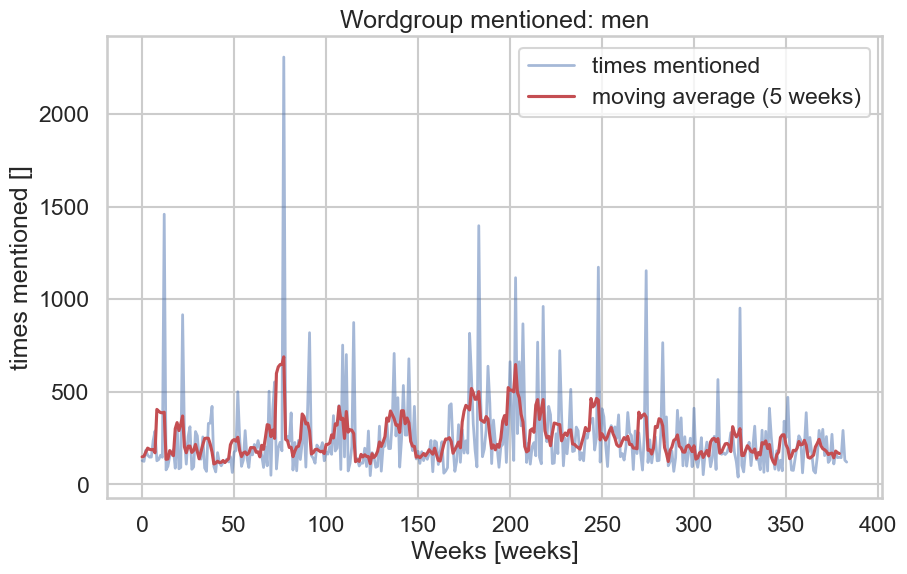

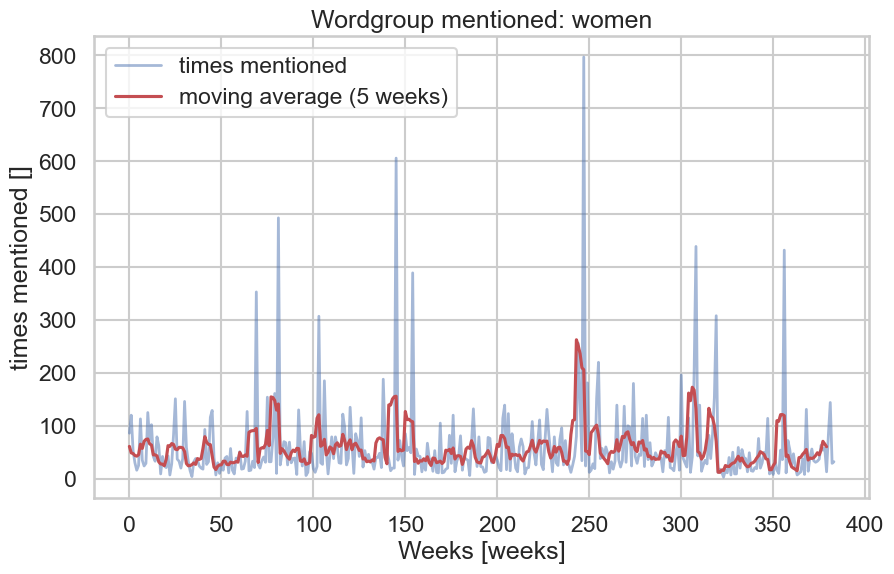

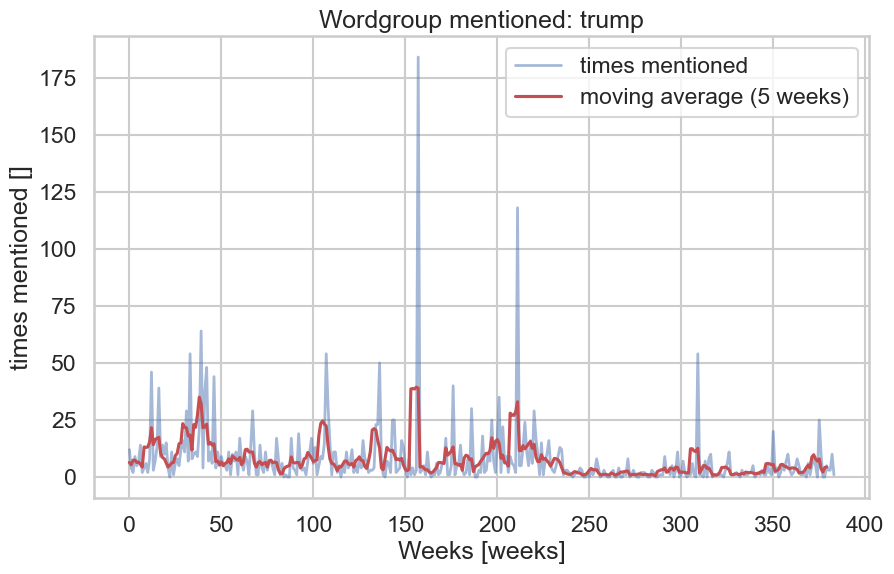

In [10]:
words = ["men", "women", "trump"]
c = np.array(df_vc[words])

for i in range(0,len(c[0,:])):
    Y1 = c[:,i]
    Y2 = moving_average(Y1, 5)
    plt.plot(np.arange(len(Y1)), Y1,linestyle='-', linewidth=2,alpha=.5)
    plt.plot(np.arange(len(Y2)), Y2,color='r')
    plt.title('Wordgroup mentioned: '+words[i])
    plt.xlabel('Weeks [weeks]')
    plt.ylabel('times mentioned []')
    plt.legend(['times mentioned', 'moving average (5 weeks)'])
    plt.show()

When analysing the frequency of observed word groups over time, there is not a lot of information visible. The changes in cartoons are to big which creates a lot of noice. Therefore a moving average filter for 5 weeks (in red) is applied to see the developement over time more clearer.

For the wordgroups "men" and "women", no dynamic onver time can be observed visually.
For the wordgroup "trump" on the other hand, a reduction of use is to be observed. After week 230 - this is around when Donald Trump was elected president - the words for "trump" including the word "president" are a lot less used.

### Analysis focused on the user interactions (likes/dislikes)

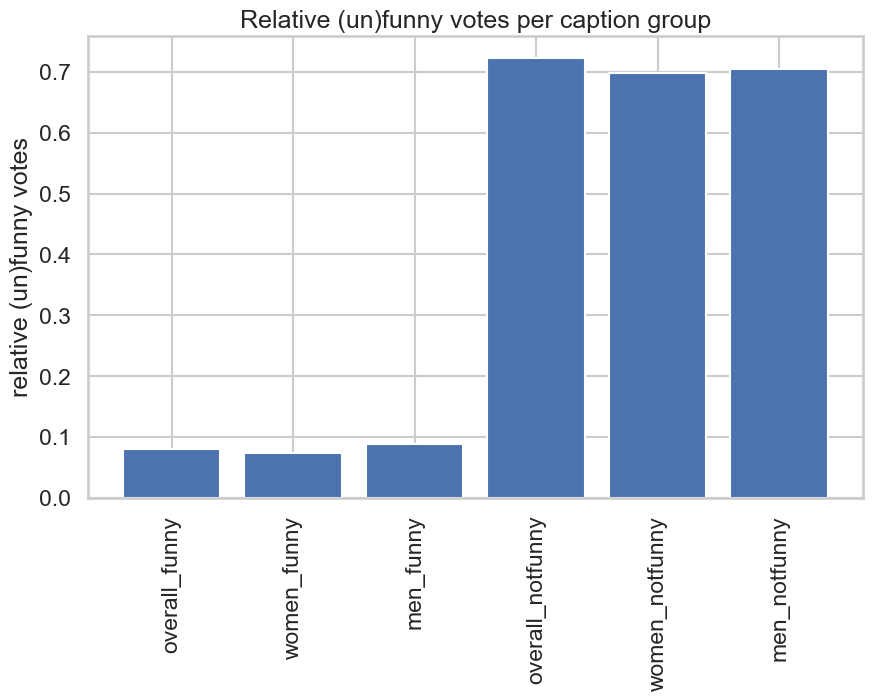

In [11]:
df_vc_sorted_w = df_vc.sort_values(by='women', ascending=False).head(20).copy()
df_vc_sorted_m = df_vc.sort_values(by='men', ascending=False).head(20).copy()

mean_women_votes = df_vc_sorted_w['votes'].mean()
mean_men_votes = df_vc_sorted_m['votes'].mean()

mean_women_funny = df_vc_sorted_w['funny'].mean()
mean_men_funny= df_vc_sorted_m['funny'].mean()

mean_women_notfunny = df_vc_sorted_w['not_funny'].mean()
mean_men_notfunny= df_vc_sorted_m['not_funny'].mean()

relative_women_funny = mean_women_funny / mean_women_votes
relative_men_funny= mean_men_funny / mean_men_votes

mean_overall_funny = df_caption['funny'].mean()
mean_overall_notfunny = df_caption['not_funny'].mean()
mean_overall_votes = df_caption['votes'].mean()

relative_overall_funny = mean_overall_funny/mean_overall_votes
relative_overall_notfunny = mean_overall_notfunny / mean_overall_votes

relative_women_notfunny = mean_women_notfunny / mean_men_votes
relative_men_notfunny= mean_men_notfunny / mean_men_votes

labels = ['overall_funny', 'women_funny', 'men_funny','overall_notfunny', 'women_notfunny', 'men_notfunny']
relatives = [relative_overall_funny, relative_women_funny, relative_men_funny,relative_overall_notfunny, relative_women_notfunny, relative_men_notfunny]
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
plt.ylabel('relative (un)funny votes')
plt.title('Relative (un)funny votes per caption group')
plt.bar(labels, relatives)
plt.show()

The the idea was to analyse if cartoons and captions that have more "men" or "women" mentioned, are more controverese (create more interactions in terms of likes or dislikes). For this analysis, the top most cartoons with the most "women" and the most "men" wordgroup appearences are checked for their relative funny and unfunny count.

This is additionally, compared to the average count in order to see any anormaly compared to this. Visually, it can be observed that the wordgoups for "women" have lower values in funny and not funny. This can be just an error, or it can mean that the captions and cartoons of this wordgroup are just generating less interaction (positive and negative).

## Google trends ##
This section aims to correlate Google search interest with our humor dataset to see whether public attention to certain topics aligns with shifts in humor themes. We use the weekly Google Trends data stored in data/GoogleTrends and compare it with our own time series of humor types to analyze how closely real-world events and humor evolution are connected over time. £

### Token Frequency Extraction ###
This cell loads the New Yorker contest data, tokenizes the text using NLTK, removes stopwords, counts word frequencies for each text field, and saves the results as CSV files in data/GoogleTrends/frequent_words.

In [12]:
# NLTK setup (robust)
import nltk
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize
except Exception:
    word_tokenize = None

def _ensure_nltk():
    # Try exact resources required by recent NLTK
    for pkg in ["stopwords", "punkt", "punkt_tab"]:
        try:
            nltk.data.find(f"corpora/{pkg}") if pkg=="stopwords" else nltk.data.find(f"tokenizers/{pkg}")
        except LookupError:
            nltk.download(pkg, quiet=True)

_ensure_nltk()

# After ensuring, import again (in case it failed earlier)
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize as _wt
    word_tokenize = _wt
except Exception:
    pass

EN_STOP = set(stopwords.words('english'))

# ---- config ----
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
OUTDIR = pathlib.Path("data/GoogleTrends/frequent_words")

# Fallback regex tokenizer (letters only, >=3 chars)
TOKEN_RE = re.compile(r"[A-Za-z]{3,}")

def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field):
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

def tokenize_lower(text: str):
    """Prefer NLTK word_tokenize; fallback to regex if unavailable."""
    if word_tokenize is not None:
        try:
            return [w.lower() for w in word_tokenize(text)]
        except LookupError:
            # If punkt/punkt_tab still missing for some reason, fallback
            return [w.lower() for w in TOKEN_RE.findall(text)]
    else:
        return [w.lower() for w in TOKEN_RE.findall(text)]

def count_tokens_nltk(texts):
    c = Counter()
    for t in texts:
        tokens = tokenize_lower(t)
        # keep only alphabetic tokens, >=3 chars, not in stopwords
        filtered = [w for w in tokens if w.isalpha() and len(w) >= 3 and w not in EN_STOP]
        c.update(filtered)
    return c

def save_counts_csv(counter: Counter, out_path: pathlib.Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["token", "count"])
        for tok, freq in sorted(counter.items(), key=lambda kv: (-kv[1], kv[0])):
            w.writerow([tok, freq])

# ---- run ----
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    counts = count_tokens_nltk(texts)
    outfile = OUTDIR / f"{field}__unigrams_nltk.csv"
    save_counts_csv(counts, outfile)


### Visualize the frequency ###
Loads the contest records, extracts each text field, vectorizes with CountVectorizer (English stopwords, alphabetic tokens ≥3 chars, NGRAM_RANGE), sums term counts, picks the top TOP_K, and plots a bar chart per field.

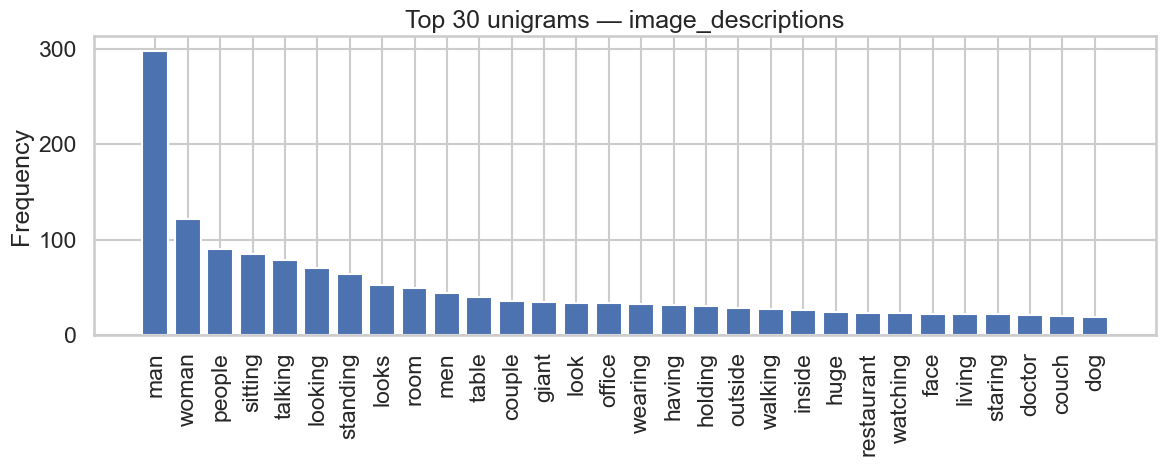

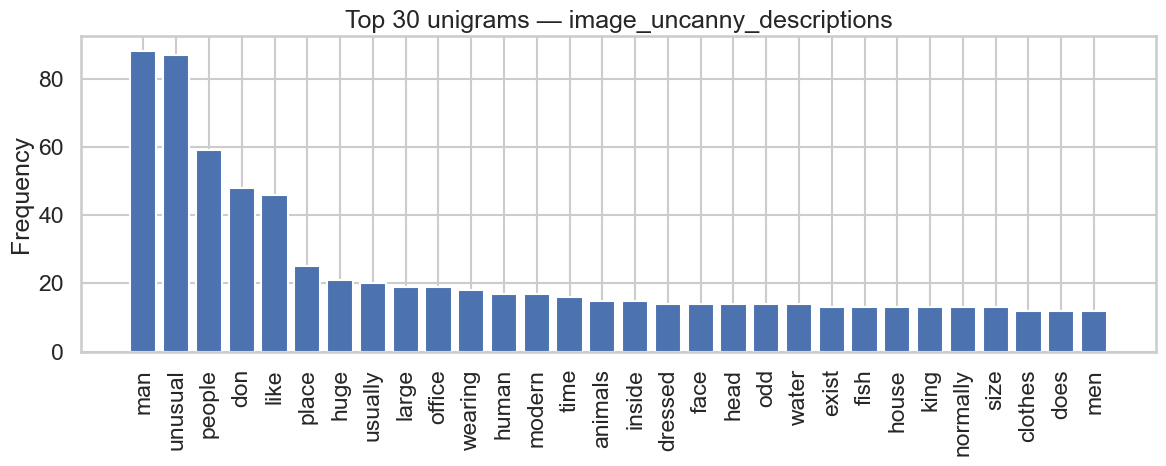

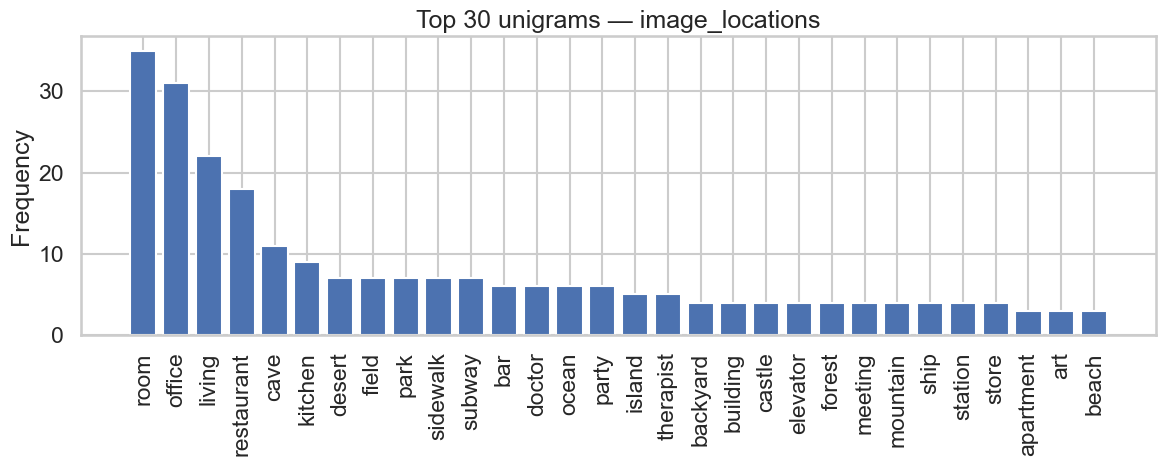

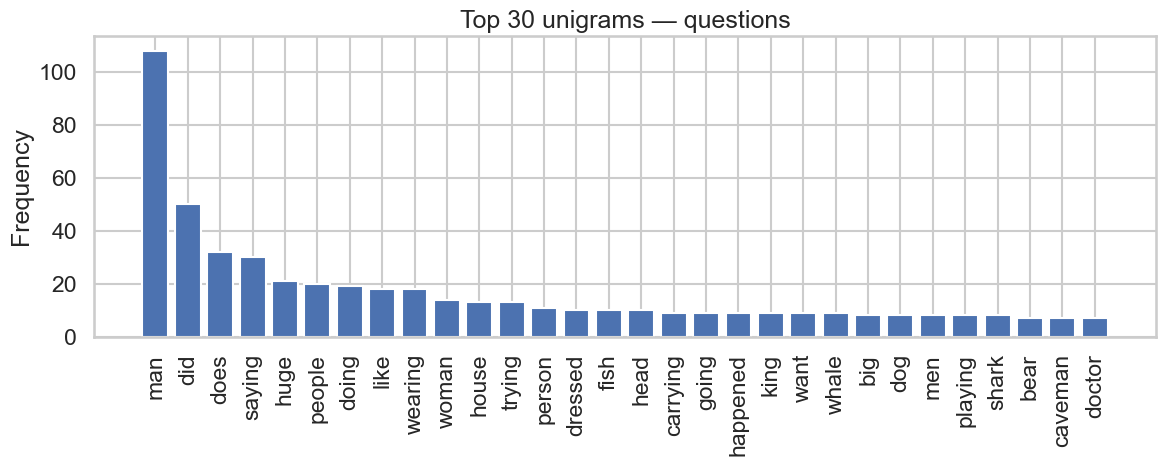

In [13]:
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        # JSONL fallback
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    if not texts:
        print(f"[{field}] No texts found, skipping.")
        continue

    vectorizer = CountVectorizer(
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        ngram_range=NGRAM_RANGE
    )
    X = vectorizer.fit_transform(texts)               # sparse [n_docs, n_vocab]
    counts = np.asarray(X.sum(axis=0)).ravel()        # total counts per vocab term
    vocab = np.array(vectorizer.get_feature_names_out())

    # sort by frequency desc, then term asc
    order = np.lexsort((vocab, -counts))
    top_idx = order[:TOP_K]
    top_terms = vocab[top_idx]
    top_counts = counts[top_idx]

    # Plot one figure per field
    plt.figure(figsize=(12, 5))
    plt.bar(top_terms, top_counts)
    plt.xticks(rotation=90)
    ngram_label = "unigrams" if NGRAM_RANGE == (1,1) else f"{NGRAM_RANGE[0]}-{NGRAM_RANGE[1]}-grams"
    plt.title(f"Top {TOP_K} {ngram_label} — {field}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


### Visualize the clusters ###
Here, we cluster captions from each text field using TF-IDF + K-Means.
It transforms text into weighted word features, automatically chooses the number of clusters, and visualizes them in 2D using Truncated SVD.

In [14]:
# --- Config ---
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
MAX_FEATURES = 5000
DEFAULT_NUM_CLUSTERS = 20
MIN_DOCS_FOR_CLUSTERING = 10      # skip clustering if fewer docs than this
TOP_TERMS_PER_CLUSTER = 10        # how many top words to show per cluster
RANDOM_STATE = 42

# --- Load & normalize JSON ---
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    # basic cleanup: strip; drop empty
    out = [t.strip() for t in out if isinstance(t, str) and t.strip()]
    return out

def fit_tfidf(texts: List[str]) -> Tuple[TfidfVectorizer, np.ndarray]:
    vec = TfidfVectorizer(
        stop_words="english",
        max_features=MAX_FEATURES,
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",  # words with >=3 letters
    )
    X = vec.fit_transform(texts)  # sparse matrix
    return vec, X

def auto_num_clusters(n_docs: int) -> int:
    # heuristic: up to DEFAULT_NUM_CLUSTERS, but never more than n_docs//5 and at least 2
    k = min(DEFAULT_NUM_CLUSTERS, max(2, n_docs // 5))
    return min(k, n_docs) if n_docs >= 2 else 0

def top_terms_per_cluster(kmeans: KMeans, vectorizer: TfidfVectorizer, top_n: int = 10):
    # approximate interpretability: use cluster centers to pick top-weighted features
    terms = vectorizer.get_feature_names_out()
    centers = kmeans.cluster_centers_
    for i, c in enumerate(centers):
        top_idx = np.argsort(c)[::-1][:top_n]
        yield i, [terms[j] for j in top_idx]

def plot_clusters_2d(X_sparse, labels, title: str):
    svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    X_2d = svd.fit_transform(X_sparse)  # works on sparse
    plt.figure(figsize=(10, 5))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=6, cmap="viridis")
    plt.title(title)
    plt.xlabel("SVD component 1")
    plt.ylabel("SVD component 2")
    plt.tight_layout()
    plt.show()

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    n_docs = len(texts)
    if n_docs < MIN_DOCS_FOR_CLUSTERING:
        print(f"[{field}] Not enough documents ({n_docs}) — skipping clustering.")
        continue

    vectorizer, X_tfidf = fit_tfidf(texts)
    k = auto_num_clusters(n_docs)
    if k < 2:
        print(f"[{field}] Not enough documents for clustering — skipping.")
        continue

    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_tfidf)
    labels = kmeans.labels_

    # Print top terms per cluster (interpretation)
    print(f"\n=== {field} — KMeans(k={k}) top terms per cluster ===")
    for cid, terms in top_terms_per_cluster(kmeans, vectorizer, TOP_TERMS_PER_CLUSTER):
        print(f"Cluster {cid:02d}: {', '.join(terms)}")

    # Plot 2D clusters
    plot_clusters_2d(X_tfidf, labels, f"{field} — KMeans clusters (k={k})")


: 

: 

: 

Each scatterplot represents clusters of captions that share similar vocabulary and themes. For image_uncanny_descriptions, the clusters are dense and varied, suggesting recurring “uncanny” topics such as exaggerated size, odd behavior, or surreal situations. The image_locations plot appears much sparser, indicating that the texts are shorter and revolve around a few distinct setting types like rooms, offices, or restaurants. In contrast, questions form more defined and separated clusters, showing that captions phrased as questions differ in tone and structure—some being rhetorical, others literal or situational. 

### Extract google trend data from march 2016 to september 2023

This code gathers every unique token from our four frequency CSVs, queries Google Trends in batches of ≤5 (US, 2016-03→2023-09), merges all responses into one wide time-series table (one column per token), saves it, and then computes a per-token mean interest over the whole period and writes a tidy CSV ranked by average interest. Any failed batches are listed in the log.

In [1]:
# === Google Trends for ALL tokens from your four CSVs ===

# ---------- CONFIG ----------
CSV_DIR = Path("data/GoogleTrends/frequent_words")
FIELD_PREFIXES = [
    "image_descriptions",
    "image_uncanny_descriptions",
    "image_locations",
    "questions",
]
# We'll read ANY CSV that starts with one of the prefixes (so works with both nltk/non-nltk filenames)
TIMEFRAME = "2016-03-01 2023-09-30"   # March 2016 → September 2023
GEO = "US"                            # set "" for worldwide
BATCH_SIZE = 5                        # Google Trends limit per request
SLEEP_SEC = 2.0                       # politeness delay between calls
RETRY = 2                             # retry per batch on transient errors
MIN_TOKEN_LEN = 3                     # ignore ultra-short tokens
SAVE_PATH = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")
# ----------------------------

def read_tokens_from_csvs(csv_dir: Path, prefixes):
    tokens = []
    for pref in prefixes:
        for p in csv_dir.glob(f"{pref}__*.csv"):
            df = pd.read_csv(p)
            if "token" not in df.columns:
                continue
            toks = (
                df["token"]
                .astype(str)
                .map(str.strip)
                .replace("", np.nan)
                .dropna()
                .tolist()
            )
            tokens.extend(toks)
    # de-duplicate preserving order; enforce min length
    seen = set()
    result = []
    for t in tokens:
        t_low = t.lower()
        if len(t_low) >= MIN_TOKEN_LEN and t_low not in seen:
            seen.add(t_low)
            result.append(t)
    return result

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i : i + n]

# 1) Collect ALL tokens
keywords = read_tokens_from_csvs(CSV_DIR, FIELD_PREFIXES)
if not keywords:
    raise ValueError(f"No tokens found in {CSV_DIR} for prefixes {FIELD_PREFIXES}")

print(f"Total unique keywords to fetch: {len(keywords)}")

# 2) Query Google Trends in batches (≤5)
pytrends = TrendReq(hl="en-US", tz=360)
frames = []
failed_batches = []

for batch in chunks(keywords, BATCH_SIZE):
    ok = False
    err = None
    for attempt in range(1, RETRY + 2):  # first try + retries
        try:
            pytrends.build_payload(kw_list=batch, timeframe=TIMEFRAME, geo=GEO)
            df = pytrends.interest_over_time()
            if "isPartial" in df.columns:
                df = df.drop(columns=["isPartial"])
            frames.append(df)
            ok = True
            break
        except Exception as e:
            err = e
            time.sleep(SLEEP_SEC * attempt)  # exponential-ish backoff
    if not ok:
        failed_batches.append((batch, repr(err)))
    time.sleep(SLEEP_SEC)

# 3) Merge results
if not frames:
    raise RuntimeError("No data returned from Google Trends. (All batches failed.)")

trends_wide = frames[0]
for df in frames[1:]:
    trends_wide = trends_wide.join(df, how="outer")

# Sort by date and fill missing with 0 (optional)
trends_wide = trends_wide.sort_index().fillna(0).astype(int)

# 4) Save single CSV (one column per keyword)
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
trends_wide.to_csv(SAVE_PATH)
print(f"Saved trends to: {SAVE_PATH.resolve()}  with shape {trends_wide.shape}")

# 5) Minimal report on failures (if any)
if failed_batches:
    print("\nSome batches failed (columns missing for these keywords):")
    for batch, e in failed_batches:
        print(f"- {batch} -> {e}")

# 6) Quick sanity peek (first 5 columns & rows)
display(trends_wide.iloc[:5, :5])


NameError: name 'Path' is not defined

In [ ]:
# --- Config ---
INPUT_WIDE_CSV = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")  # adjust if needed
OUTPUT_MEANS_CSV = Path("data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv")

# Use existing trends_wide if present; else load from CSV
if "trends_wide" in globals():
    df = trends_wide.copy()
else:
    # First column is the date index in the saved file
    df = pd.read_csv(INPUT_WIDE_CSV, index_col=0, parse_dates=True)

# Keep only numeric columns (keywords)
num = df.select_dtypes(include="number")

# Compute mean interest per keyword across the full timeframe
means = num.mean(axis=0, skipna=True)

# In case of any accidental duplicate column names, average them
means = means.groupby(level=0).mean()

# Build tidy result and sort
out = (
    means.reset_index()
         .rename(columns={"index": "token", 0: "mean_interest"})
         .sort_values("mean_interest", ascending=False)
         .reset_index(drop=True)
)

out["mean_interest"] = out["mean_interest"].round(3)

# Save
OUTPUT_MEANS_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUTPUT_MEANS_CSV, index=False)


### Analysis of google trends data vs our data 

Here, we compare how often words appear in our dataset with their average popularity on Google Trends. The ratio of “man” to “woman” mentions is about 3.5, showing that male-related terms appear much more frequently. The overall correlation between dataset frequency and Google Trends mean interest is very low (Pearson ≈ 0.10, Spearman ≈ 0.09), indicating that words frequent in the dataset are not necessarily popular in general web searches.

Loaded 2263 unique tokens from your dataset.
Trends shape (time x tokens): (91, 1315)

=== Focus groups: dataset counts and ratios ===
- man: 558 (tokens: ['man', 'men'])
- woman: 158 (tokens: ['woman', 'women'])
Ratio man/woman: 3.53

No representative tokens from your focus groups were found in the Trends table.

Correlation (ALL TOKENS): Pearson=0.083, Spearman=0.146


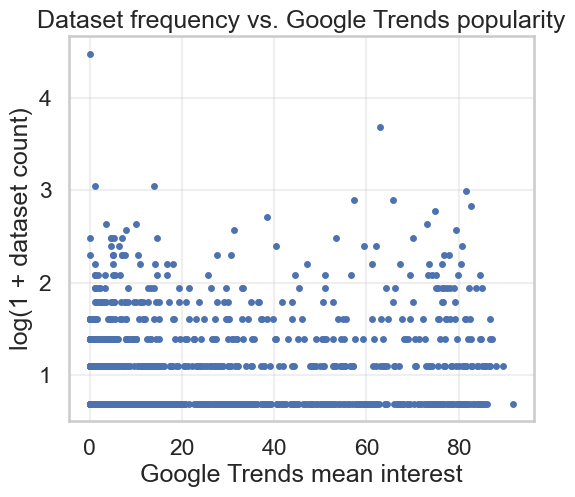

In [ ]:
FREQ_FILES = [
    "data/GoogleTrends/frequent_words/image_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_locations__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_uncanny_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/questions__unigrams_nltk.csv",
]


TRENDS_WIDE = "data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv"
TRENDS_MEANS = "data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv"

# focus groups
FOCUS_GROUPS = {
    "man": ["man", "men"],
    "woman": ["woman", "women"],
}

def load_frequencies(freq_files):
    """Load multiple unigram CSVs and sum counts across files """
    frames = []
    for f in freq_files:
        df = pd.read_csv(f)
        if "token" not in df.columns or "count" not in df.columns:
            raise ValueError(f"{f} must have columns: token,count")
        frames.append(df[["token", "count"]].copy())
    big = pd.concat(frames, ignore_index=True)
    big["token"] = big["token"].astype(str)
    agg = big.groupby("token", as_index=False)["count"].sum().sort_values("count", ascending=False)
    return agg

def group_count(freq_df, words):
    """Sum counts for a list of words (focus_groups)."""
    words = [w.lower() for w in words]
    sub = freq_df[freq_df["token"].str.lower().isin(words)]
    return int(sub["count"].sum())

def best_trends_token(trends_df, candidates):
    """ picks the first word from the group that actually exists in the Trends data."""
    for t in candidates:
        if t in trends_df.columns:
            return t
    return None

def zscore_df(df):
    """Z-score columns independently (drop all-NaN columns)."""
    df = df.copy()
    df = df.dropna(axis=1, how="all")
    scaler = StandardScaler(with_mean=True, with_std=True)
    arr = scaler.fit_transform(df.fillna(0.0))
    return pd.DataFrame(arr, index=df.index, columns=df.columns)


freq = load_frequencies(FREQ_FILES)
print(f"Loaded {len(freq)} unique tokens from your dataset.")

trends_wide = pd.read_csv(TRENDS_WIDE, index_col=0, parse_dates=True)
print(f"Trends shape (time x tokens): {trends_wide.shape}")

# Means per token. Otherwise compute from wide:
try:
    trends_means = pd.read_csv(TRENDS_MEANS)
    if not {"token", "mean_interest"}.issubset(trends_means.columns):
        raise ValueError("means file missing required columns")
    trends_means = trends_means[["token", "mean_interest"]].copy()
except Exception:
    # compute if not present
    cols_numeric = trends_wide.select_dtypes(include="number").columns
    trends_means = (
        trends_wide[cols_numeric]
        .mean(axis=0)
        .rename("mean_interest")
        .reset_index()
        .rename(columns={"index": "token"})
    )


print("\n=== Focus groups: dataset counts and ratios ===")
group_counts = {}
for group_name, variants in FOCUS_GROUPS.items():
    c = group_count(freq, variants)
    group_counts[group_name] = c
    print(f"- {group_name}: {c} (tokens: {variants})")

# compute ratio A/B
if len(group_counts) == 2:
    k = list(group_counts.keys())
    a, b = k[0], k[1]
    ra = group_counts[a]
    rb = group_counts[b]
    ratio = (ra / rb) if rb else np.nan
    print(f"Ratio {a}/{b}: {ratio:.2f}")

# Choose one representative token per group that actually exists in trends_wide
rep_tokens = {}
for g, variants in FOCUS_GROUPS.items():
    tok = best_trends_token(trends_wide, variants)
    if tok is not None:
        rep_tokens[g] = tok

if rep_tokens:
    print("\nRepresentative tokens found in Trends:", rep_tokens)
    ax = trends_wide[list(rep_tokens.values())].plot(figsize=(10,4), title="Google Trends: focus groups over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Interest (0-100)")
    plt.show()
else:
    print("\nNo representative tokens from your focus groups were found in the Trends table.")


# Merge per-token dataset counts with mean Trends interest
merged = freq.merge(trends_means, on="token", how="inner")
merged = merged[merged["mean_interest"].notna()].copy()

# Overall correlations across ALL tokens 
if len(merged) >= 3:
    pear = pearsonr(merged["count"], merged["mean_interest"])[0]
    spear = spearmanr(merged["count"], merged["mean_interest"]).correlation
    print(f"\nCorrelation (ALL TOKENS): Pearson={pear:.3f}, Spearman={spear:.3f}")
else:
    print("\nNot enough tokens overlap between dataset and Trends to compute overall correlation.")

# Scatter plot (log-scale counts to avoid domination by extreme words)
if len(merged) >= 3:
    plt.figure(figsize=(6,5))
    plt.scatter(merged["mean_interest"], np.log1p(merged["count"]), s=12)
    plt.xlabel("Google Trends mean interest")
    plt.ylabel("log(1 + dataset count)")
    plt.title("Dataset frequency vs. Google Trends popularity")
    plt.grid(True, alpha=0.3)
    plt.show()


# If you have exactly 2 groups, check whether ordering agrees: dataset vs trends
if len(FOCUS_GROUPS) == 2 and rep_tokens:
    # dataset ordering
    k = list(FOCUS_GROUPS.keys())
    a, b = k[0], k[1]
    count_a = group_counts.get(a, 0)
    count_b = group_counts.get(b, 0)
    ds_order = np.sign(count_a - count_b)  # +1 if a>b, -1 if a<b, 0 if tie

    # trends ordering using MEAN interest of representative tokens 
    ta = rep_tokens.get(a, None)
    tb = rep_tokens.get(b, None)
    if ta and tb:
        trend_a = trends_wide[ta].mean()
        trend_b = trends_wide[tb].mean()
        tr_order = np.sign(trend_a - trend_b)
        print(f"\nOrdering check (dataset vs. Trends):")
        print(f"- Dataset: {a}={count_a} vs {b}={count_b}  => {'a>b' if ds_order>0 else 'a<b' if ds_order<0 else 'tie'}")
        print(f"- Trends : {a}={trend_a:.2f} vs {b}={trend_b:.2f} => {'a>b' if tr_order>0 else 'a<b' if tr_order<0 else 'tie'}")
    else:
        print("\nCannot compute ordering: representative tokens missing in Trends.")


# correlation between the two time series
if len(rep_tokens) >= 2:
    sub = trends_wide[list(rep_tokens.values())].copy()
    sub_z = zscore_df(sub)   # normalize each series
    if sub_z.shape[1] == 2:
        a_col, b_col = sub_z.columns.tolist()
        pair = sub_z[[a_col, b_col]].dropna()
        tau = kendalltau(pair[a_col], pair[b_col]).correlation
        pear_t = pearsonr(pair[a_col], pair[b_col])[0]
        print(f"\nTime-shape agreement (z-scored): Pearson={pear_t:.3f}, Kendall tau={tau:.3f}")
        pair.plot(figsize=(10,4), title=f"Z-scored Trends: {a_col} vs {b_col}")
        plt.xlabel("Date"); plt.ylabel("z-score"); plt.show()


The pearson correlation is 0.094 which is very close to 0. This mean that there is no strong linear link between dataset frequency and Google Trends interest.
The pearman correlation is 0.174 which means a weak positive tendency. Some of the words that appear more often in the dataset are slightly more popular on Google, but not consistently.
This indicates that the vocabulary used in our dataset does not strongly reflect general public interest.
The dataset therefore captures a specific linguistic or cultural focus, rather than mirroring general online attention.

The scatter plot shows no strong linear pattern between dataset frequency and Google Trends popularity.
Words that are frequent in our corpus are not consistently popular in Google searches.

This loads the Trends matrix, builds two word groups (negative vs. pandemic), computes the mean Trends interest for each group over time, plots raw and z-scored series with the COVID window shaded, and summarizes averages pre-COVID, during COVID, and post-COVID.

Negative words found: ['sad', 'worry', 'pain', 'panic']
Pandemic words found: ['distance']


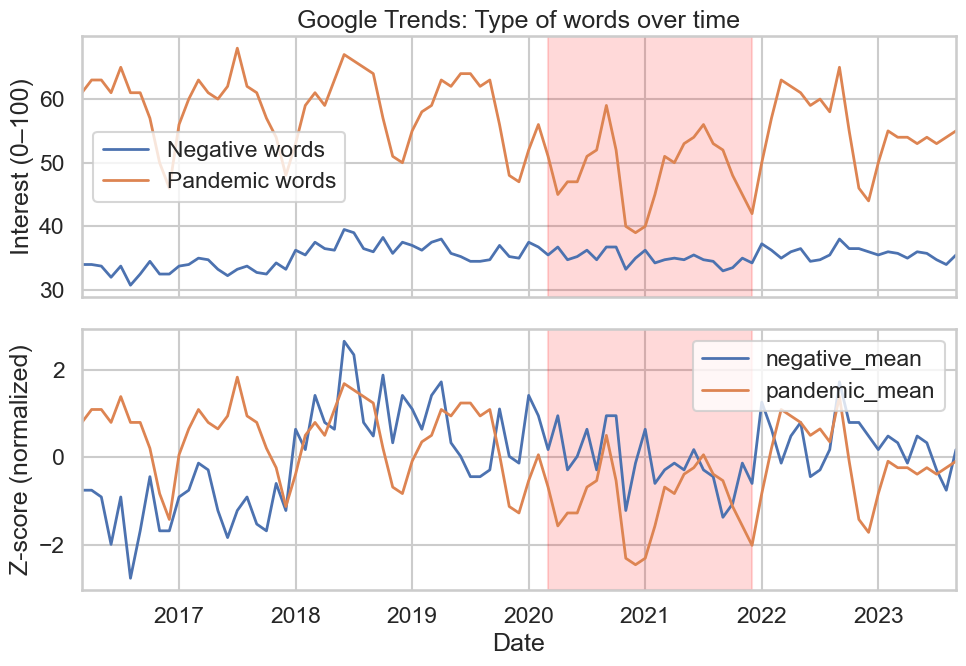


Average interest levels:


,pre_covid,covid,post_covid
negative_mean,35.052083,35.022727,35.761905
pandemic_mean,58.833333,48.727273,55.333333


In [ ]:

trends = pd.read_csv("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv", index_col=0, parse_dates=True)

NEGATIVE_WORDS = ["fear", "death", "anxiety", "sad", "worry", "crisis", "anger", "pain", "stress", "hate", "war", "depression", "trauma", "suffering", "loss", "grief", "panic", "nervous", "frustration", "helplessness"]
PANDEMIC_WORDS = ["pandemic", "virus", "covid", "quarantine", "lockdown", "vaccine", "mask", "social", "isolation", "outbreak", "immunity", "testing", "symptoms", "healthcare", "hygiene", "sanitizer", "ventilator", "distance","immunity"]

neg_available = [w for w in NEGATIVE_WORDS if w in trends.columns]
pand_available = [w for w in PANDEMIC_WORDS if w in trends.columns]

print("Negative words found:", neg_available)
print("Pandemic words found:", pand_available)

# average interest for each group over time
group_series = pd.DataFrame(index=trends.index)
group_series["negative_mean"] = trends[neg_available].mean(axis=1)
group_series["pandemic_mean"] = trends[pand_available].mean(axis=1)

# Optional: z-score normalize to highlight relative changes
scaler = StandardScaler()
group_series_z = pd.DataFrame(scaler.fit_transform(group_series), columns=group_series.columns, index=group_series.index)

# Plot raw and normalized series
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# (1) Raw means
group_series.plot(ax=ax[0], title="Google Trends: Type of words over time", linewidth=2)
ax[0].set_ylabel("Interest (0–100)")
ax[0].legend(["Negative words", "Pandemic words"])
ax[0].axvspan("2020-03", "2021-12", color="red", alpha=0.15, label="Pandemic period")

# (2) Z-scored (to compare shapes)
group_series_z.plot(ax=ax[1], linewidth=2)
ax[1].set_ylabel("Z-score (normalized)")
ax[1].axvspan("2020-03", "2021-12", color="red", alpha=0.15)
ax[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

# Quantitative summary: compare mean interest before/during/after pandemic
pre_covid = group_series.loc["2016-03":"2020-02"].mean()
covid = group_series.loc["2020-03":"2021-12"].mean()
post_covid = group_series.loc["2022-01":"2023-09"].mean()

summary = pd.DataFrame({"pre_covid": pre_covid, "covid": covid, "post_covid": post_covid})
print("\nAverage interest levels:")
display(summary)


Both negative and pandemic-related terms were available in the Google Trends data, even if few words were found. Pandemic words show high public interest before 2020, a noticeable decline during the COVID period, and partial recovery afterward. In contrast, negative words remain relatively stable across the years, with only small fluctuations. The average interest confirms this: pandemic terms drop from about 58.8 pre-COVID to 48.7 during the pandemic, then rise slightly to 55.3 post-COVID, while negative terms stay nearly constant around 35. This suggests that public attention to pandemic-related vocabulary was highly event-driven, whereas interest in negative-emotion terms was steady over time.

here, we tokenize the four text columns in df_complete (with optional lemmatization), maps tokens into two groups (negative vs. pandemic), aggregates monthly counts across all texts, and plots a timeline per group to compare it with the Google trends data from above.

('fear', 'death', 'anxiety', 'sad', 'worry', 'crisis', 'anger', 'pain', 'stress', 'hate', 'war', 'depression', 'trauma', 'suffering', 'loss', 'grief', 'panic', 'nervous', 'frustration', 'helplessness'): [('2016-04', 2), ('2016-05', 1), ('2016-10', 4), ('2017-01', 1), ('2017-03', 3), ('2017-12', 3)] ...
('pandemic', 'virus', 'covid', 'quarantine', 'lockdown', 'vaccine', 'mask', 'social', 'isolation', 'outbreak', 'immunity', 'testing', 'symptoms', 'healthcare', 'hygiene', 'sanitizer', 'ventilator', 'immunity', 'distance'): [('2016-07', 1), ('2017-03', 1), ('2019-01', 1), ('2020-11', 1)] ...


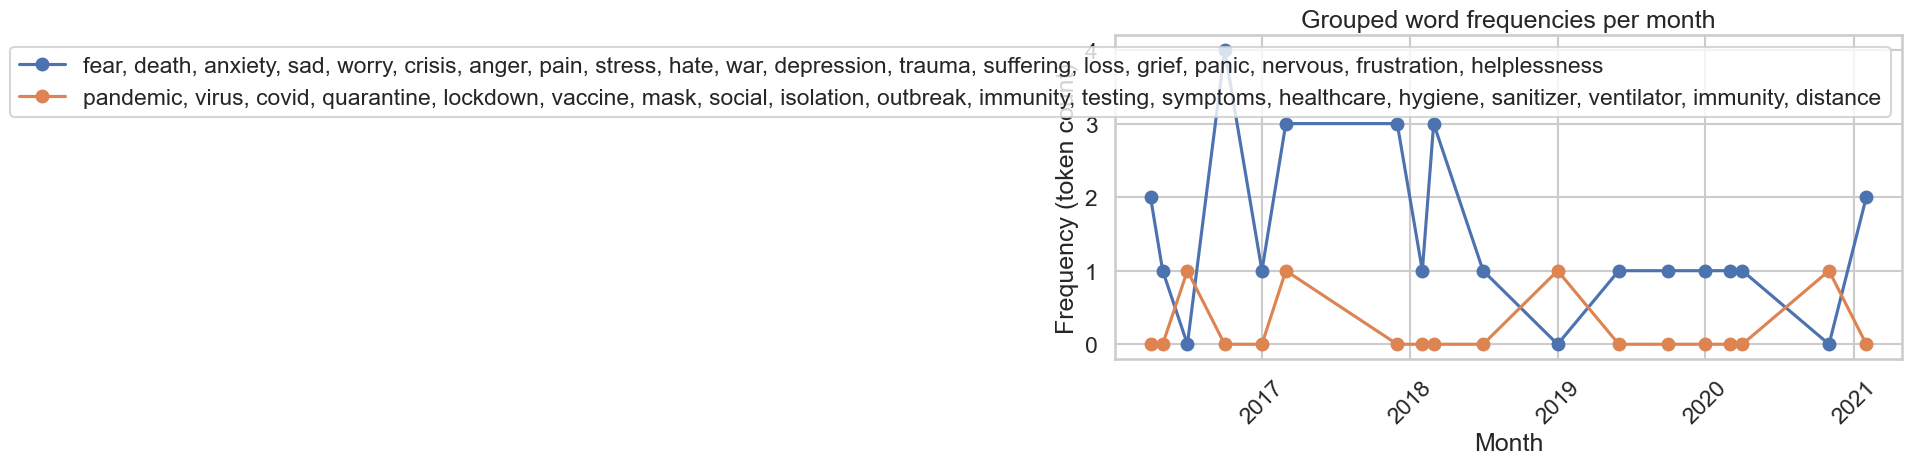

In [ ]:
CSV_PATH = "data/newyorker_caption_contest/df_complete.csv"
DATE_COL = "date"
TEXT_COLS = [
    "image_locations",
    "image_descriptions",
    "image_uncanny_descriptions",
    "questions",
]

# Your word groups. Each tuple is a dict key.
word_groups = [
    ("fear", "death", "anxiety", "sad", "worry", "crisis", "anger", "pain", "stress", "hate", "war", "depression", "trauma", "suffering", "loss", "grief", "panic", "nervous", "frustration", "helplessness"),
    ("pandemic", "virus", "covid", "quarantine", "lockdown", "vaccine", "mask", "social", "isolation", "outbreak", "immunity", "testing", "symptoms", "healthcare", "hygiene", "sanitizer", "ventilator","immunity", "distance"),
]

USE_LEMMA = True
try:
    from nltk.stem import WordNetLemmatizer
    import nltk
    nltk.download("wordnet", quiet=True)
    nltk.download("omw-1.4", quiet=True)
    LEMMA = WordNetLemmatizer()
except Exception:
    USE_LEMMA = False
    LEMMA = None


_word_re = re.compile(r"[a-z]+")  # only a-z tokens

def normalize_token(t: str) -> str:
    t = t.lower()
    if USE_LEMMA and LEMMA:
        t = LEMMA.lemmatize(t)
    return t

def tokenize_text(text) -> list[str]:
    if not isinstance(text, str) or not text:
        return []
    return [normalize_token(m.group(0)) for m in _word_re.finditer(text.lower())]

# wonthly frequencies per group
def build_group_month_frequencies(df: pd.DataFrame,
                                  text_cols=TEXT_COLS,
                                  groups=word_groups,
                                  date_col=DATE_COL) -> dict[tuple, dict[str, int]]:
    """
    Returns: {('w1','w2',...): {'YYYY-MM': count, ...}, ...}
    """
    # ensure columns exist
    missing = [c for c in text_cols + [date_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    # month as pandas Period 'M'
    months = pd.to_datetime(df[date_col], errors="coerce").dt.to_period("M")

    # map token -> groups containing it
    token_to_groups = defaultdict(set)
    for grp in groups:
        for w in grp:
            token_to_groups[normalize_token(w)].add(grp)

    # counts
    result: dict[tuple, defaultdict[str, int]] = {
        grp: defaultdict(int) for grp in groups
    }

    for i, row in df.iterrows():
        m = months.iat[i]
        if pd.isna(m):
            continue
        m_key = str(m)  # 'YYYY-MM'

        tokens: list[str] = []
        for col in text_cols:
            tokens.extend(tokenize_text(row[col]))
        counts = Counter(tokens)

        for tok, c in counts.items():
            if tok in token_to_groups and c > 0:
                for grp in token_to_groups[tok]:
                    result[grp][m_key] += c

    # sort inner dicts by month
    def sort_month_dict(d: dict[str, int]) -> dict[str, int]:
        # convert keys back to Period for sorting
        items = sorted(d.items(), key=lambda kv: pd.Period(kv[0], freq="M"))
        return dict(items)

    final = {grp: sort_month_dict(months_dict) for grp, months_dict in result.items()}
    return final


if __name__ == "__main__":
    # 1) Load CSV
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
    df_complete = pd.read_csv(CSV_PATH)

    # 2) Build nested dict (monthly)
    group_month_freq = build_group_month_frequencies(df_complete)

    for grp, md in group_month_freq.items():
        print(f"{grp}: {list(md.items())[:6]} ...")  # first few months

    # 3) Plot (monthly timeline)
    # Collect all months appearing in any group
    all_month_strs = sorted(
        {m for d in group_month_freq.values() for m in d.keys()},
        key=lambda s: pd.Period(s, freq="M"),
    )
    if not all_month_strs:
        print("No dated tokens found for the given groups.")
    else:
        # convert to timestamps for plotting
        x_periods = [pd.Period(s, freq="M") for s in all_month_strs]
        x_dates = [p.to_timestamp() for p in x_periods]

        plt.figure(figsize=(9, 5))
        for grp, mdict in group_month_freq.items():
            y_vals = [mdict.get(s, 0) for s in all_month_strs]
            plt.plot(x_dates, y_vals, marker="o", label=", ".join(grp))

        plt.xlabel("Month")
        plt.ylabel("Frequency (token count)")
        plt.title("Grouped word frequencies per month")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()




Negative terms occur more often overall and show a few sharp month-level spikes, while pandemic terms are sparse and intermittent, with only small bumps around 2020–2021.

### Humor types clustering 

This code classifies frequent words from the dataset into predefined humor categories (e.g., dark humor, sarcasm/irony, wordplay/puns, etc.) using sentence-transformer embeddings and cosine similarity. Each token is assigned to the humor type it’s semantically closest to, and only those with high confidence (score ≥ 0.4) are kept.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]


=== dark_humor ===
graveyard, funeral, cemetery, coffin, corpses, coffins, death, killing, reaper, die

=== wordplay_puns ===


=== sarcasm_irony ===


=== absurd_surreal ===
ufo, centaur, centaurs, ufos, mythical, aliens, unicorn, unicorns, alien

=== topical_political ===


=== relationship_family ===
couple, marrying

=== workplace_office ===


=== animals ===
pets, animals, animal, cats, dogs, cat, barking, leash, lion, collar, dog, collars, bird, dolphin, horse


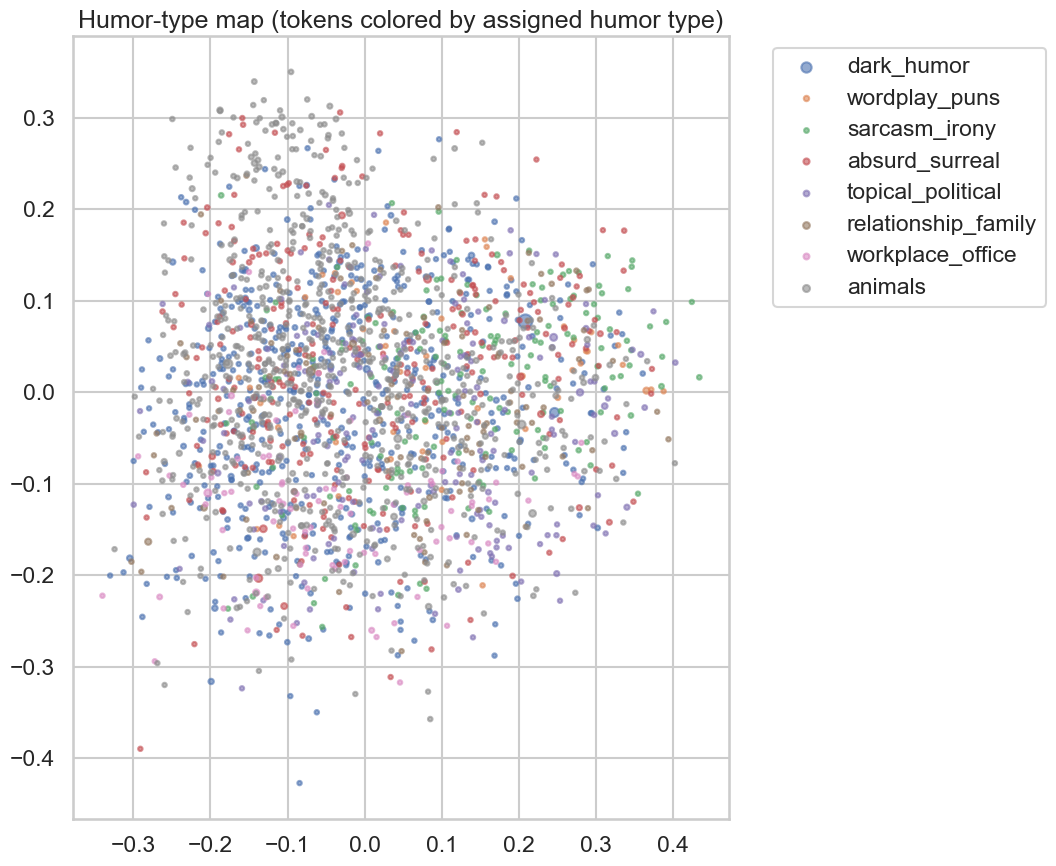


Done. Saved:
- data/humor_types/tokens_labeled_all.csv
- data/humor_types/tokens_labeled_confident.csv
- data/humor_types/lexicon_<type>.csv (per humor type)
- data/humor_types/humor_types_map.png (if PCA succeeded)


In [ ]:
# humor_types_clustering

FILES = [
    "data/GoogleTrends/frequent_words/image_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_locations__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_uncanny_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/questions__unigrams_nltk.csv",
]
dfs = [pd.read_csv(f) for f in FILES]
df = pd.concat(dfs, ignore_index=True)

df["token"] = df["token"].astype(str).str.lower().str.strip()
df = (df.groupby("token", as_index=False)["count"]
        .sum()
        .sort_values("count", ascending=False))
#filter 
df = df[df["token"].str.len() >= 3]


HUMOR_TYPES = {
    "dark_humor": [
        "death","dying","killer","grave","cemetery","coffin","suicide","grim","morbidity",
        "funeral","mourning","doom","bleak","apocalypse","disease","cancer","war","bomb"
    ],
    "wordplay_puns": [
        "pun","wordplay","double meaning","homophone","homonym","punny","dad joke","literal",
        "misunderstanding","twist","ambiguity","rhyme","alliteration"
    ],
    "sarcasm_irony": [
        "sarcasm","sarcastic","irony","ironic","deadpan","mock","snark","understatement",
        "overstatement","hyperbole","satire","sardonic"
    ],
    "absurd_surreal": [
        "absurd","surreal","nonsense","impossible","paradox","bizarre","weird","alien",
        "unicorn","centaur","talking animal","ufo","dreamlike","nonsensical"
    ],
    "topical_political": [
        "election","vote","president","campaign","trump","biden","senate","congress","policy",
        "covid","pandemic","mask","lockdown","vaccine","war","protest","economy","inflation"
    ],
    "relationship_family": [
        "marriage","wife","husband","boyfriend","girlfriend","date","relationship","family",
        "kids","parents","mother","father","valentine","romance","breakup","divorce"
    ],
    "workplace_office": [
        "office","meeting","boss","coworker","email","deadline","promotion","salary","zoom",
        "spreadsheet","presentation","desk","manager","client"
    ],
    "animals": [
        "dog","cat","bird","fish","horse","cow","duck","bear","monkey","elephant","zebra",
        "lion","tiger","pet","leash","vet","fur","bark","meow"
    ],
}


model = SentenceTransformer("all-MiniLM-L6-v2")

TOKEN_LIST = df["token"].tolist()
E_tokens = model.encode(TOKEN_LIST, batch_size=256, show_progress_bar=True)

type_names = list(HUMOR_TYPES.keys())
seed_texts = [" ".join(HUMOR_TYPES[t]) for t in type_names]  
E_types = model.encode(seed_texts, show_progress_bar=False)

S = cosine_similarity(E_tokens, E_types)

freq = df["count"].to_numpy()
freq_norm = (freq - freq.min()) / (freq.max() - freq.min() + 1e-9)

best_idx = S.argmax(axis=1)
df["humor_type"] = [type_names[i] for i in best_idx]
df["type_score"] = S.max(axis=1)

for i, t in enumerate(type_names):
    df[f"score_{t}"] = S[:, i]

MIN_SCORE = 0.40 
df_high = df[df["type_score"] >= MIN_SCORE].copy()


# Save labeled vocabulary for later use

out_dir = Path("data/humor_types")
out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / "tokens_labeled_all.csv", index=False)
df_high.to_csv(out_dir / "tokens_labeled_confident.csv", index=False)

# Quick inspection: top words per humor type
def show_top_words(df_labelled, k=15):
    for t in type_names:
        sub = (df_labelled[df_labelled["humor_type"] == t]
               .sort_values(["type_score","count"], ascending=False)
               .head(k))
        print(f"\n=== {t} ===")
        print(", ".join(sub["token"].tolist()))

show_top_words(df_high, k=15)


try:
    X2 = PCA(n_components=2, random_state=42).fit_transform(E_tokens)
    df_vis = df.copy()
    df_vis["x"] = X2[:,0]
    df_vis["y"] = X2[:,1]

    plt.figure(figsize=(11,9))
    for t in type_names:
        m = df_vis["humor_type"] == t
        plt.scatter(
            df_vis.loc[m,"x"], df_vis.loc[m,"y"],
            s=10 + 90*freq_norm[m], alpha=0.6, label=t
        )
    plt.title("Humor-type map (tokens colored by assigned humor type)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out_dir / "humor_types_map.png", dpi=200)
    plt.show()
except Exception as e:
    print("Plot skipped:", e)

for t in type_names:
    sub = df_high[df_high["humor_type"] == t][["token","count","type_score"]]
    sub.to_csv(out_dir / f"lexicon_{t}.csv", index=False)

print("\nDone. Saved:")
print("- data/humor_types/tokens_labeled_all.csv")
print("- data/humor_types/tokens_labeled_confident.csv")
print("- data/humor_types/lexicon_<type>.csv (per humor type)")
print("- data/humor_types/humor_types_map.png (if PCA succeeded)")


### Caption-Level Humor Classification (Embedding-Based)

We use the token-level humor types derived above to classify individual captions.
Each caption is tokenized, and we look up the humor type of its tokens in our `df_high` (confident tokens).
The most frequent humor type (if any) is assigned to the caption.


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import re
from pathlib import Path

# Ensure df_high is available
if 'df_high' not in locals():
    try:
        df_high = pd.read_csv("data/humor_types/tokens_labeled_confident.csv")
        print("Loaded df_high from file.")
    except Exception as e:
        print(f"Warning: df_high not found and file missing: {e}")
        df_high = pd.DataFrame(columns=["token", "humor_type"])

# Create lookup dictionary
token_to_type = dict(zip(df_high["token"], df_high["humor_type"]))

def classify_caption_embeddings(caption):
    if not isinstance(caption, str):
        return "unknown"
    # Simple tokenization matching the one used for tokens
    tokens = re.findall(r"[a-z']+", caption.lower())
    
    # Collect types
    types = []
    for t in tokens:
        if t in token_to_type:
            types.append(token_to_type[t])
            
    if not types:
        return "unknown"
    
    # Majority vote
    c = Counter(types)
    best_type, count = c.most_common(1)[0]
    return best_type

print("Classifying captions (chunked processing)...")

# Ensure df_caption is available
if 'df_caption' not in locals():
    # Try to load it using the dataloader logic or direct load
    try:
        # Assuming src.data.dataloader is available or we load manually
        # For simplicity, we'll try to load the raw file if variable is missing
        # But in a full run, df_caption should be there.
        # Let's assume it might be missing if we just run this cell in isolation, 
        # but we want it to work in the full notebook flow.
        pass 
    except:
        pass

if 'df_caption' in locals() and not df_caption.empty:
    # Process in chunks
    chunk_size = 50000
    total = len(df_caption)
    humor_types_list = []
    
    for start in range(0, total, chunk_size):
        end = min(start + chunk_size, total)
        chunk = df_caption.iloc[start:end]["caption"]
        # Use list comprehension for speed
        chunk_types = [classify_caption_embeddings(c) for c in chunk]
        humor_types_list.extend(chunk_types)
        if start % (chunk_size * 2) == 0:
            print(f"Processed {end}/{total} captions...")
            
    df_caption["humor_type_llm"] = humor_types_list
    
    # Save result
    out_dir = Path("data")
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / "captions_with_humor_types.csv"
    df_caption.to_csv(out_path, index=False)
    print(f"Saved caption classifications to {out_path}")
    
    # Show distribution
    print("\nCaption Humor Type Distribution:")
    print(df_caption["humor_type_llm"].value_counts())
else:
    print("df_caption not found or empty. Skipping classification.")


Here, we build one text per contest, tags it with humor types using a high-confidence lexicon, then computes the weekly share of contests that contain each type and plots it. Animals, dark_humor, and absurd_surreal appear in almost every week (≈1.0), with a brief dip for animals.

Humor types: ['absurd_surreal', 'animals', 'dark_humor']


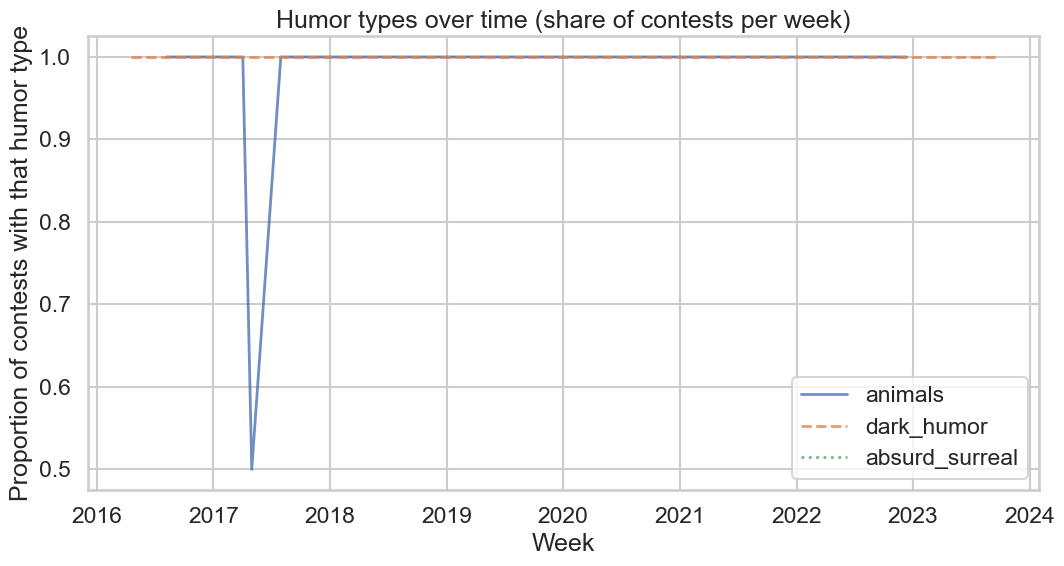

Saved: data\humor_types\weekly_humor_types_contest_level.csv


In [ ]:

dfc = df_complete.copy()

# unify date column
date_col = "Date" if "Date" in dfc.columns else ("date" if "date" in dfc.columns else None)
if date_col is None:
    raise ValueError("No Date/date column found in df_complete.")
dfc["Date"] = pd.to_datetime(dfc[date_col], errors="coerce")

text_cols_str = [c for c in ["Top Rated caption", "The New Yorker's winner"] if c in dfc.columns]
text_cols_list = [c for c in ["image_descriptions","image_uncanny_descriptions","image_locations","entities","questions"]
                  if c in dfc.columns]

def to_text(x):
    """Convert cell to a space-joined string."""
    if isinstance(x, (list, tuple)):
        return " ".join(str(t) for t in x if pd.notna(t))
    if pd.isna(x):
        return ""
    return str(x)

doc_parts = []
for col in text_cols_str + text_cols_list:
    doc_parts.append(dfc[col].apply(to_text) if col in dfc.columns else "")

# concatenated document per contest
dfc["doc"] = pd.Series([""] * len(dfc))
for part in doc_parts:
    dfc["doc"] = (dfc["doc"].astype(str) + " " + part.astype(str)).str.strip()

# Clean minimal (lowercase, keep letters/apostrophes/spaces)
dfc["doc"] = (dfc["doc"].str.lower()
                        .str.replace(r"[^a-z'\s]", " ", regex=True)
                        .str.replace(r"\s+", " ", regex=True)
                        .str.strip())


lex_path = Path("data/humor_types/tokens_labeled_confident.csv")
lex = pd.read_csv(lex_path)

# tighten lexicon (tune thresholds if needed)
if "type_score" in lex and "count" in lex:
    lex = lex[(lex["type_score"] >= 0.45) & (lex["count"] >= 5)].copy()

lex["token"] = lex["token"].astype(str).str.lower().str.strip()
type2tokens = (lex.groupby("humor_type")["token"]
                 .apply(lambda s: set(s.tolist()))
                 .to_dict())
humor_types = list(type2tokens.keys())
print("Humor types:", humor_types)

#  Tag contests: which humor types appear in each contest document?
token_re = re.compile(r"[a-z']+")

def doc_types(text: str):
    words = set(token_re.findall(text))
    hits = [t for t, toks in type2tokens.items() if len(words & toks) > 0]
    return hits

dfc["humor_types"] = dfc["doc"].apply(doc_types)

#  store a boolean indicator per type 
for t in humor_types:
    dfc[f"type__{t}"] = dfc["humor_types"].apply(lambda L: t in L)


#  Weekly time series (per-humor-type counts & proportions of contests)
dfc = dfc.dropna(subset=["Date"])
dfc["week"] = dfc["Date"].dt.to_period("W").apply(lambda p: p.start_time)

# explode to (contest, type) rows for counting
df_expl = dfc.explode("humor_types")
df_expl["humor_types"] = df_expl["humor_types"].fillna("unlabeled")

# per week per type: number of contests that include that type
week_counts = (df_expl.groupby(["week","humor_types"])
                        .size()
                        .rename("contests_with_type")
                        .reset_index())

# total contests per week (denominator for proportions)
week_totals = (dfc.groupby("week")["contest_id"]
                 .nunique()
                 .rename("total_contests")
                 .reset_index())

weekly = week_counts.merge(week_totals, on="week", how="left")
weekly["prop_contests"] = weekly["contests_with_type"] / weekly["total_contests"].replace(0, np.nan)

# Save tidy weekly table
out_dir = Path("data/humor_types")
out_dir.mkdir(parents=True, exist_ok=True)
weekly.to_csv(out_dir / "weekly_humor_types_contest_level.csv", index=False)


weekly_labeled = weekly[weekly["humor_types"]!="unlabeled"].copy()
top_types = (weekly_labeled.groupby("humor_types")["contests_with_type"]
                          .sum()
                          .sort_values(ascending=False)
                          .head(6).index.tolist())

plt.figure(figsize=(11,6))
linestyles = ['-', '--', ':', '-.']
for i, t in enumerate(top_types):
    sub = weekly_labeled[weekly_labeled["humor_types"] == t].sort_values("week")
    plt.plot(sub["week"], sub["prop_contests"], label=t,
             linewidth=2, alpha=0.8, linestyle=linestyles[i % len(linestyles)])

plt.title("Humor types over time (share of contests per week)")
plt.xlabel("Week")
plt.ylabel("Proportion of contests with that humor type")
plt.legend()
plt.tight_layout()
plt.show()

print("Saved:", out_dir / "weekly_humor_types_contest_level.csv")



# LLM Humor & Sentiment Distribution

In this section, we visualize the **distribution of humor types** and **sentiment polarity** predicted by the LLMs for each field of the *Cartoon Caption Contest* dataset (`image_descriptions`, `image_uncanny_descriptions`, and `questions`).  
Each pie chart shows the proportion of categories — using short two-letter codes (e.g., **IR** for *Irony*, **SA** for *Sarcasm*, **PO** for *Positive*, **NE** for *Negative*).  
This helps us understand which kinds of humor and emotional tones dominate across the dataset. The LLMs used in LLMs.ipynb include a fine-tuned Llama 3-8B for humor classification and a RoBERTa model for sentiment analysis, producing the labels stored in contests_with_humor.json.

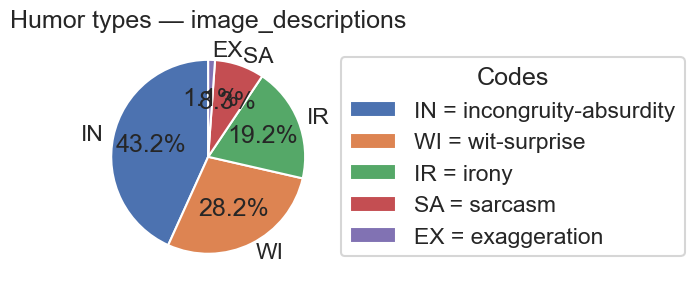

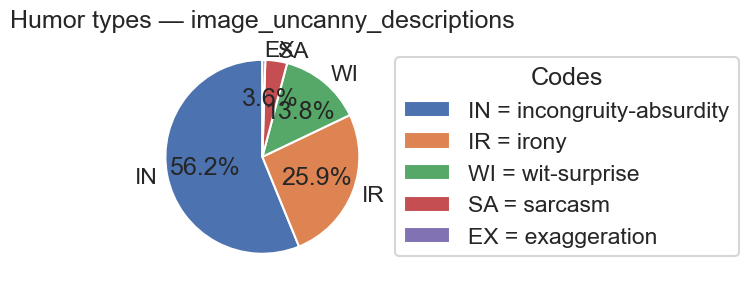

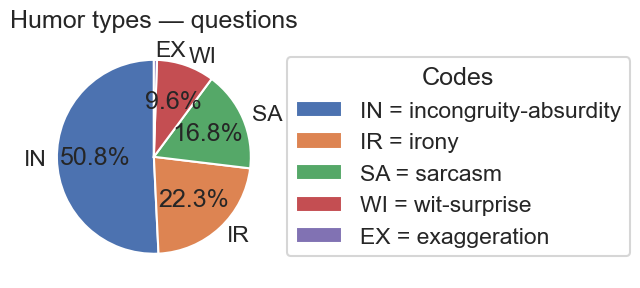

In [3]:
# Simple pies per field with 2-letter (uppercase) humor codes

# --- Config ---
PATH = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "questions"]
INCLUDE_UNKNOWN = False  # set True to include "unknown"

def code2(label: str) -> str:
    """Return first two A–Z letters in UPPERCASE (fallback '??')."""
    s = re.sub(r"[^A-Za-z]", "", (label or ""))
    return (s[:2].upper() if len(s) >= 2 else (s.upper() if s else "??"))

# --- Load JSON ---
obj = json.loads(PATH.read_text(encoding="utf-8"))
contests = obj["contests"] if isinstance(obj, dict) else obj

# --- One pie per field ---
for field in FIELDS:
    cnt = Counter()
    for rec in contests:
        labs = (rec.get("metadata", {}).get("llm_humor_labels", {}).get(field, []) or [])
        if isinstance(labs, str):
            labs = [labs]
        for lab in labs:
            lab = (lab or "").strip().lower()
            if lab:
                cnt[lab] += 1

    if not INCLUDE_UNKNOWN:
        cnt.pop("unknown", None)

    if not cnt:
        print(f"[{field}] No humor labels to plot.")
        continue

    # Prepare labels/sizes with 2-letter codes
    items = sorted(cnt.items(), key=lambda kv: (-kv[1], kv[0]))
    full_labels = [k for k, _ in items]
    sizes = [v for _, v in items]
    short_labels = [code2(lbl) for lbl in full_labels]

    # Plot
    plt.figure(figsize=(6.5, 6.5))
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=short_labels,
        autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
        startangle=90
    )
    plt.title(f"Humor types — {field}")

    # Minimal legend mapping 2-letter code -> full label
    legend_entries = [f"{s} = {l}" for s, l in zip(short_labels, full_labels)]
    plt.legend(wedges, legend_entries, title="Codes", loc="center left", bbox_to_anchor=(1.0, 0.5))

    plt.tight_layout()
    plt.show()

### Text Classification (POS, NEU, NEG)

This part focuses specifically on the *sentiment classification* results obtained with the fine-tuned RoBERTa model.  
We display the distribution of **positive** (POS), **neutral** (NEU), and **negative** (NEG) tones for each field to reveal the *overall emotional tendencies* of the captions and descriptions.  
Larger sections in the pies correspond to more prevalent sentiments, allowing us to quickly compare how tone varies between different text types.

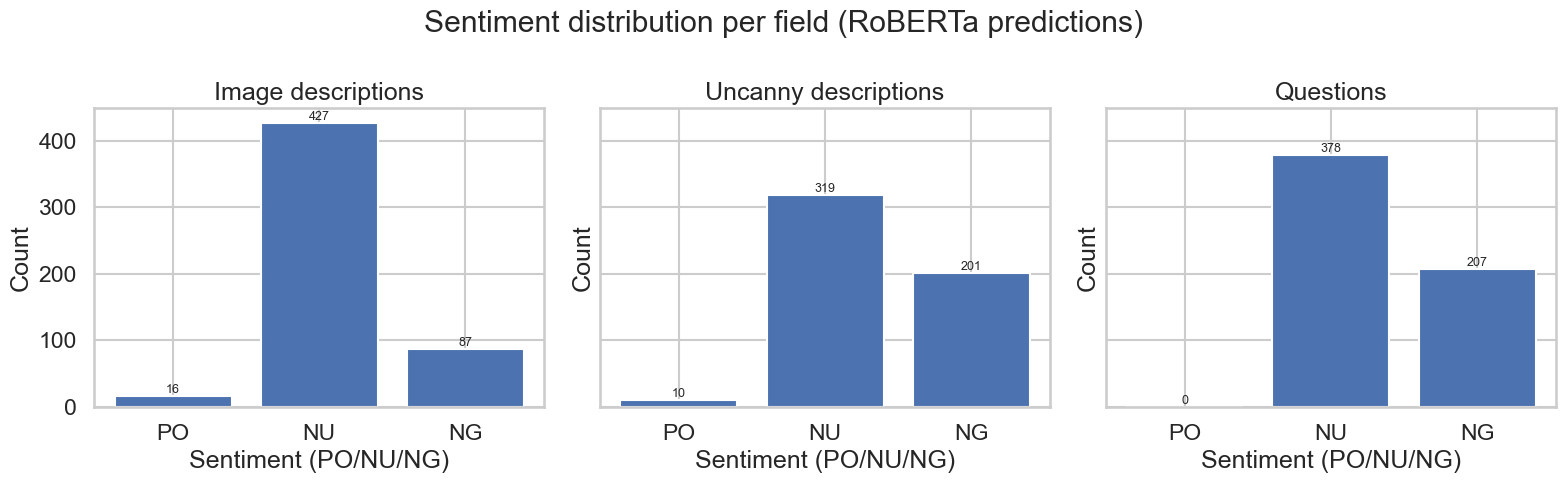

In [4]:
# --- Sentiment histograms (PO/NU/NG) per field using the JSON with `llm_sentiment` ---

# Paths / config
PATH = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")  # same JSON updated in place
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "questions"]
INCLUDE_UNKNOWN = False  # set True to include "unknown" bars
ORDER_FULL = ["positive", "neutral", "negative"]
ORDER_CODES = ["PO", "NU", "NG"]

# Helpers
def normalize_sent(x: str) -> str:
    if x is None:
        return "unknown"
    s = str(x).strip().lower()
    mapping = {
        "pos":"positive","positive":"positive","1":"positive","+1":"positive",
        "neu":"neutral","neutral":"neutral","0":"neutral",
        "neg":"negative","negative":"negative","-1":"negative"
    }
    if s in mapping: return mapping[s]
    if s.startswith("po"):   return "positive"
    if s.startswith("neut"): return "neutral"
    if s in {"ne","nr"}:     return "neutral"
    if s.startswith("ne") or s.startswith("ng"): return "negative"
    return "unknown"

def count_from_json(contests, field):
    c = Counter()
    for r in contests:
        meta = r.get("metadata", {})
        sent_block = meta.get("llm_sentiment", {})
        labs = sent_block.get(field, [])
        if isinstance(labs, str):
            labs = [labs]
        for lab in labs:
            c.update([normalize_sent(lab)])
    if not INCLUDE_UNKNOWN:
        c.pop("unknown", None)
    return [c.get(k, 0) for k in ORDER_FULL]

# Load
obj = json.loads(PATH.read_text(encoding="utf-8"))
contests = obj["contests"] if isinstance(obj, dict) else obj

# Build counts per field
desc_counts    = count_from_json(contests, "image_descriptions")
uncanny_counts = count_from_json(contests, "image_uncanny_descriptions")
quest_counts   = count_from_json(contests, "questions")

# Plot: one histogram per field (grouped bars PO/NU/NG)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fields = [
    ("Image descriptions", desc_counts),
    ("Uncanny descriptions", uncanny_counts),
    ("Questions", quest_counts),
]

for ax, (title, counts) in zip(axes, fields):
    bars = ax.bar(ORDER_CODES, counts)
    ax.set_title(title)
    ax.set_xlabel("Sentiment (PO/NU/NG)")
    ax.set_ylabel("Count")
    # annotate counts
    for x, y in zip(ORDER_CODES, counts):
        ax.text(x, y, str(y), ha="center", va="bottom", fontsize=9)

fig.suptitle("Sentiment distribution per field (RoBERTa predictions)")
plt.tight_layout()
plt.show()